# Laboratorio 9: Proyecto Final: Agenda Medios

Como hemos visto a lo largo de los laboratorios, extraer datos no es una meta por sí misma, sino el punto de partida del Análisis Crítico. Hoy aplicaremos este concepto sobre la principal noticia del día.

En el Lab 004 generamos un extracto directo de la portada del diario nacional La Nación (`lanacion_portada.json`). En la presente actividad demostraremos las redes tangibles en las que se enmarca la realidad política e informativa de nuestra sociedad actual; es decir, **analizaremos la Agenda Setting y los focos de atención del medio periodístico**.

Al finalizar este cuaderno de ejercicios, empaquetaremos estos hallazgos analíticos utilizando lo aprendido en el Lab 000: diseñaremos un *Dashboard* Interactivo con la librería **Gradio**.

## Consigna 1: Carga y Exploración del Corpus

A partir del archivo JSON suministrado (`lanacion_portada.json`), lea el contenido empleando la librería principal de manejo estadístico `pandas`. Inspeccione el encuadre estructural (forma y primeros 5 renglones) a fines de asegurar la fidelidad del traspaso de registros.

In [ ]:
# EJERCICIO: Importar bibliotecas base (pandas y json), leer el archivo e imprimir el encabezado del DataFrame.
import pandas as pd
import json

In [4]:
archivo_json = "lanacion_portada.json"
df = pd.read_json(archivo_json)
df.head(5)

,seccion,titulo
0,General,Sin prensa ni transmisión. Karina Milei dio ot...
1,General,“Inaceptables”. Meloni toma partido en la fero...
2,General,Nuevo revés para Burford. La Cámara de Nueva Y...
3,General,Del “ataúd” de Orban a Islamabad. El doble tra...
4,General,Será “eliminada” de inmediato. Comenzó el bloq...


In [6]:
with open(archivo_json, 'r', encoding='utf-8') as f:
    contenido = f.read()

print(contenido)

[
    {
        "seccion": "General",
        "titulo": "Sin prensa ni transmisión. Karina Milei dio otra señal de apoyo a Adorni y hubo un fuerte operativo para evitar un escrache"
    },
    {
        "seccion": "General",
        "titulo": "“Inaceptables”. Meloni toma partido en la feroz pelea entre el Papa y Trump"
    },
    {
        "seccion": "General",
        "titulo": "Nuevo revés para Burford. La Cámara de Nueva York suspende todas las apelaciones del juicio YPF"
    },
    {
        "seccion": "General",
        "titulo": "Del “ataúd” de Orban a Islamabad. El doble traspié de un Vance cada vez más impopular que expone su debilidad política"
    },
    {
        "seccion": "General",
        "titulo": "Será “eliminada” de inmediato. Comenzó el bloqueo de EE.UU. en Ormuz con una amenaza de Trump e Irán advirtió que responderá"
    },
    {
        "seccion": "General",
        "titulo": "Comodoro Py. Las dos prestamistas de Adorni declararon que les debe US$70.000 más los in

## Consigna 2: Visualización Temática de Agenda Periodística

Con nuestra tabla constituida, buscaremos responder una pregunta clave de investigación: **¿Qué temática decidió priorizar jerárquicamente la línea editorial en su portada de hoy?**

Filtre valores nulos y estructure una representación categórica (ejemplo `sns.barplot()` con orientación horizontal) de modo que exponga de manera irrefutable qué secciones ostentan la mayor cantidad de aparatos editoriales (notas emitidas). Agregue un título informativo y recuerde aplicar principios rigurosos de Data-Ink Ratio.

In [ ]:
# EJERCICIO: Graficar las frecuencias de las secciones (Categoría) del conjunto de noticias.
# veo si hay valores nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   seccion  139 non-null    str  
 1   titulo   139 non-null    str  
dtypes: str(2)
memory usage: 2.3 KB


In [15]:
frecuencias = df['seccion'].value_counts()
print(df['seccion'].value_counts())

seccion
ESPECTÁCULOS              23
EXPERIENCIA LIVING        16
TE PUEDE INTERESAR        12
General                   10
MÁS LEÍDAS                10
MÁS NOTICIAS               9
ACTUALIDAD                 8
POLÍTICA Y ECONOMÍA        8
OTROS TEMAS                8
PROPIEDADES                7
LIFESTYLE                  7
OPINIÓN                    6
HISTORIAS Y PERSONAJES     5
DEPORTES                   4
EL MUNDO                   3
TECNOLOGÍA                 3
Name: count, dtype: int64


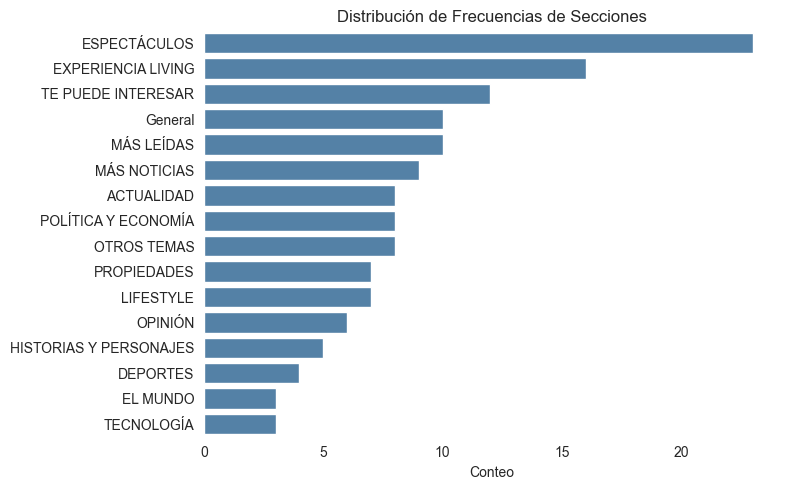

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white") # Fondo blanco puro, sin rejillas
plt.figure(figsize=(8, 5))

sns.barplot(x=frecuencias.values, 
            y=frecuencias.index, 
            color="steelblue",  # Un solo color para evitar distracciones
            edgecolor=None)   # Eliminar bordes de las barras
plt.title('Distribución de Frecuencias de Secciones')
sns.despine(left=True, bottom=True)
plt.xlabel('Conteo')
plt.ylabel('')
plt.tight_layout() # Para que no se corten las etiquetas largas
plt.show()

## Consigna 3: Pesos del Lenguaje (Redes Léxicas)

Con la temática confirmada, deconstruiremos semánticamente esos focos de atención aislando el lenguaje que envuelve al contenido principal. Emplearemos el *Lollipop Chart* abordado en metodologías previas para proyectar las 15 palabras clave con mayor iteración masiva a lo largo de *toda la portada* titular.

Identifique las iteraciones que se formulan más allá de conectores y artículos nulos (*stop words*). ¿Cuál de estos nodos terminológicos monopoliza el marco informativo de la presente fecha?

In [19]:
# EJERCICIO: Extraer el Top 15 de palabras más utilizadas en los títulos (ignorando stop words) y representarlas en un Lollipop Chart.
stopwords_es = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para", 
    "con", "no", "una", "su", "al", "lo", "como", "más", "pero", "sus", "le", "ya", "o", "este", 
    "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me", "hasta", 
    "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno", "les", "ni", 
    "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí", "antes", "algunos", 
    "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto", "esa", "estos", "mucho", "quienes", 
    "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas", "algo", "nosotros", "mi", 
    "mis", "tú", "te", "ti", "tu", "tus", "ellas", "nosotras", "vosotros", "vosotras", "os", "mío", 
    "mía", "míos", "mías", "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas", "nuestro", 
    "nuestra", "nuestros", "nuestras", "vuestro", "vuestra", "vuestros", "vuestras", "esos", "esas", 
    "estoy", "estás", "está", "estamos", "estáis", "están", "esté", "estés", "estemos", "estéis", 
    "estén", "estaré", "estarás", "estará", "estaremos", "estaréis", "estarán", "estaría", "estarías", 
    "estaríamos", "estaríais", "estarían", "estaba", "estabas", "estábamos", "estabais", "estaban", 
    "estuve", "estuviste", "estuvo", "estuvimos", "estuvisteis", "estuvieron", "estuviera", "estuvieras", 
    "estuviéramos", "estuvierais", "estuvieran", "estuviese", "estuvieses", "estuviésemos", "estuvieseis", 
    "estuviesen", "estando", "estado", "estada", "estados", "estadas", "soy", "eres", "es", "somos", 
    "sois", "son", "sea", "seas", "seamos", "seáis", "sean", "seré", "serás", "será", "seremos", 
    "seréis", "serán", "sería", "serías", "seríamos", "seríais", "serían", "era", "eras", "éramos", 
    "erais", "eran", "fui", "fuiste", "fue", "fuimos", "fuisteis", "fueron", "fuera", "fueras", 
    "fuéramos", "fuerais", "fueran", "fuese", "fueses", "fuésemos", "fueseis", "fuesen", "siendo", 
    "sido", "tengo", "tienes", "tiene", "tenemos", "tenéis", "tienen", "tenga", "tengas", "tengamos", 
    "tengáis", "tengan", "tendré", "tendrás", "tendrá", "tendremos", "tendréis", "tendrán", "tendría", 
    "tendrías", "tendríamos", "tendríais", "tendrían", "tenía", "tenías", "teníamos", "teníais", 
    "tenían", "tuve", "tuviste", "tuvo", "tuvimos", "tuvisteis", "tuvieron", "tuviera", "tuvieras", 
    "tuviéramos", "tuvierais", "tuvieran", "tuviese", "tuvieses", "tuviésemos", "tuvieseis", 
    "tuviesen", "teniendo", "tenido", "tenida", "tenidos", "tenidas", "hubo"
}



In [21]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('spanish'))
print(stop_words)

{'es', 'vuestras', 'habremos', 'tuviste', 'estadas', 'estuvieron', 'tendrás', 'vosotras', 'fueras', 'estuviésemos', 'habríais', 'tenga', 'serían', 'muy', 'hay', 'estéis', 'tened', 'no', 'fuimos', 'sobre', 'nos', 'fuiste', 'habido', 'tus', 'esa', 'tengáis', 'porque', 'estuvieras', 'fuisteis', 'a', 'el', 'tengamos', 'estaríamos', 'estas', 'tu', 'han', 'estará', 'donde', 'estarías', 'del', 'ha', 'estuvo', 'tenidas', 'estarás', 'nuestra', 'tú', 'al', 'habiendo', 'estando', 'tengan', 'habíamos', 'habríamos', 'hubieran', 'tuvisteis', 'mi', 'estaban', 'por', 'hube', 'pero', 'sintiendo', 'mí', 'como', 'hayamos', 'hayan', 'había', 'tenidos', 'contra', 'estaría', 'tengo', 'para', 'esos', 'estad', 'os', 'hayáis', 'está', 'hubieras', 'suya', 'suyo', 'ella', 'más', 'sois', 'eres', 'fueron', 'mis', 'en', 'uno', 'tuyos', 'la', 'habré', 'tuvierais', 'tuviésemos', 'tiene', 'seré', 'o', 'vuestra', 'fueseis', 'hubiésemos', 'entre', 'este', 'tenida', 'tuvieseis', 'estuviste', 'sentidas', 'fuese', 'tuviero

In [36]:
stopwords_es.update(stop_words)

In [38]:

# Función para limpiar y tokenizar el texto final
def depurar_texto(texto, stopwords=stopwords_es):
    texto_minusculas = texto.lower()
    # Limitamos los carácteres (borramos puntuación usando regex)
    texto_sin_puntuacion = re.sub(r'[^\w\s]', '', texto_minusculas)
    lista_palabras = texto_sin_puntuacion.split()

    palabras_importantes = []
    for palabra in lista_palabras:
        if palabra not in stopwords:
            palabras_importantes.append(palabra)

    return palabras_importantes

In [30]:
from collections import Counter

corpus = " ".join(df['titulo'].astype(str)).lower()
palabras_filtradas = depurar_texto(corpus)
top_15 = pd.DataFrame(Counter(palabras_filtradas).most_common(15), columns=['palabra', 'repeticion'])

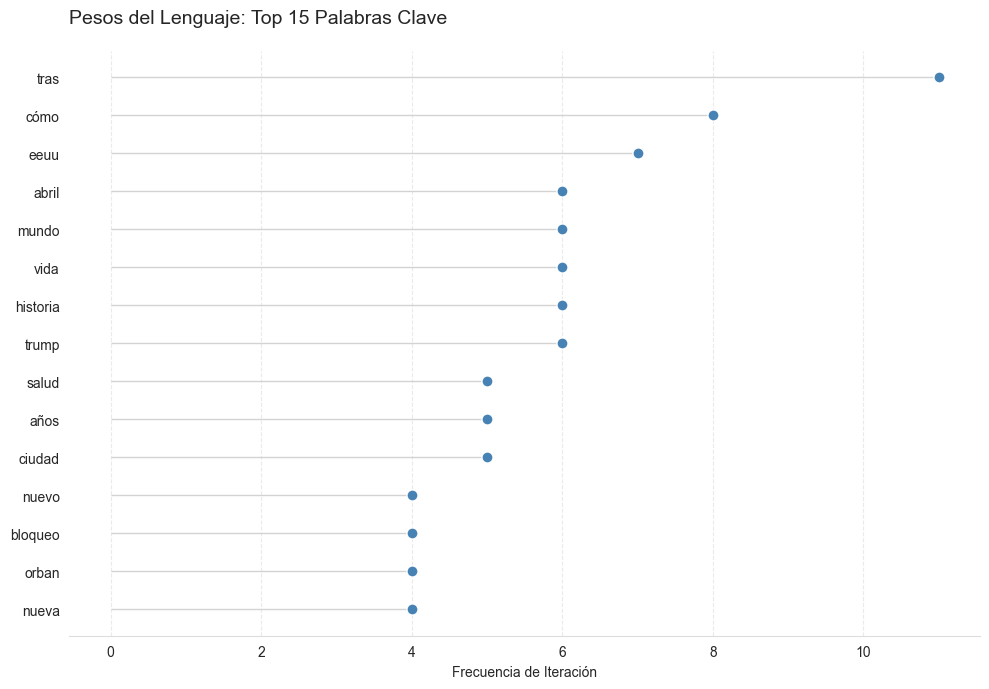

In [54]:
import matplotlib.pyplot as plt

# Ordenar para que la más frecuente esté arriba
top_15 = top_15.sort_values(by='repeticion')

plt.figure(figsize=(10, 7), facecolor='white')

# Crear las líneas (el "palo" del lollipop)
plt.hlines(y=top_15['palabra'], xmin=0, xmax=top_15['repeticion'], 
           color='lightgray', linewidth=1)

# Crear los nodos (el "caramelo")
plt.plot(top_15['repeticion'], top_15['palabra'], "o", 
         markersize=8, color='steelblue', markeredgecolor='white')

# Limpieza total de "tinta" innecesaria (Principios de Tufte)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')

plt.title('Pesos del Lenguaje: Top 15 Palabras Clave', loc='left', fontsize=14, pad=20)
plt.xlabel('Frecuencia de Iteración')
plt.grid(axis='x', linestyle='--', alpha=0.4) # Grid tenue solo para referencia

plt.tight_layout()
plt.show()

In [39]:
# veo que se repite tras (preposición) y cómo (adverbio). Puedo agregarlas a las 
# stopword
stopwords_es.update({'cómo', 'tras'})

## Consigna Final: Dashboard Dinámico de Sentido con Gradio

Integrar y escalar el diseño. Acaba de confirmar metodológicamente la agenda principal y el vocabulario dominador del periódico entero. Ahora envuélvalo funcionalmente convirtiéndolo en una Interface Web que logre desglosar el contenido respondiendo filtros particulares del investigador.

Deberá programar una Interfaz Gradio (`gr.Interface` o `gr.Blocks`) que exponga un **Desplegable (Dropdown)** poblado con las Secciones halladas (`Política`, `Economía`, `Sociedad`, etc.). 
La selección del usuario invocará una función que:
1. Cribe al DataFrame dejando solamente artículos pertenecientes a dicha sección.
2. Genere dos *outputs* (Salidas): 
    * Una tabla (`gr.Dataframe` o texto) enumerando puros títulos resultantes de esa sección selecta.
    * El gráfico del analizador de pesos (`Lollipop de frecuencias`) re-computado exclusivamente sobre el vocabulario de la sección elegida.

> Al correr la Interfaz, notará instantáneamente cómo el eje material y discursivo muta violentamente de polaridad con el simple acto interactivo de mover de 'Política' a 'Cultura'.

In [ ]:
# filtrar dataframe

def seccion(df: pd.DataFrame, nombre_seccion: str):
    nombre_seccion = nombre_seccion.lower()
  
   
    return df.loc[df['seccion'].str.lower() == nombre_seccion.lower()]

In [57]:
set(df['seccion'])

{'ACTUALIDAD',
 'DEPORTES',
 'EL MUNDO',
 'ESPECTÁCULOS',
 'EXPERIENCIA LIVING',
 'General',
 'HISTORIAS Y PERSONAJES',
 'LIFESTYLE',
 'MÁS LEÍDAS',
 'MÁS NOTICIAS',
 'OPINIÓN',
 'OTROS TEMAS',
 'POLÍTICA Y ECONOMÍA',
 'PROPIEDADES',
 'TE PUEDE INTERESAR',
 'TECNOLOGÍA'}

In [55]:
def grafico_seccion(df, nombre_seccion):
    data = seccion(df, nombre_seccion)
    corpus = " ".join(data['titulo'].astype(str)).lower()
    palabras_filtradas = depurar_texto(corpus)
    top_15 = pd.DataFrame(Counter(palabras_filtradas).most_common(15), columns=['palabra', 'repeticion'])
    # Ordenar para que la más frecuente esté arriba
    top_15 = top_15.sort_values(by='repeticion')

    plt.figure(figsize=(10, 7), facecolor='white')

    # Crear las líneas (el "palo" del lollipop)
    plt.hlines(y=top_15['palabra'], xmin=0, xmax=top_15['repeticion'], 
            color='lightgray', linewidth=1)

    # Crear los nodos (el "caramelo")
    plt.plot(top_15['repeticion'], top_15['palabra'], "o", 
            markersize=8, color='steelblue', markeredgecolor='white')

    # Limpieza total de "tinta" innecesaria (Principios de Tufte)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#DDDDDD')

    plt.title('Pesos del Lenguaje: Top 15 Palabras Clave', loc='left', fontsize=14, pad=20)
    plt.xlabel('Frecuencia de Iteración')
    plt.grid(axis='x', linestyle='--', alpha=0.4) # Grid tenue solo para referencia

    plt.tight_layout()
    plt.show()

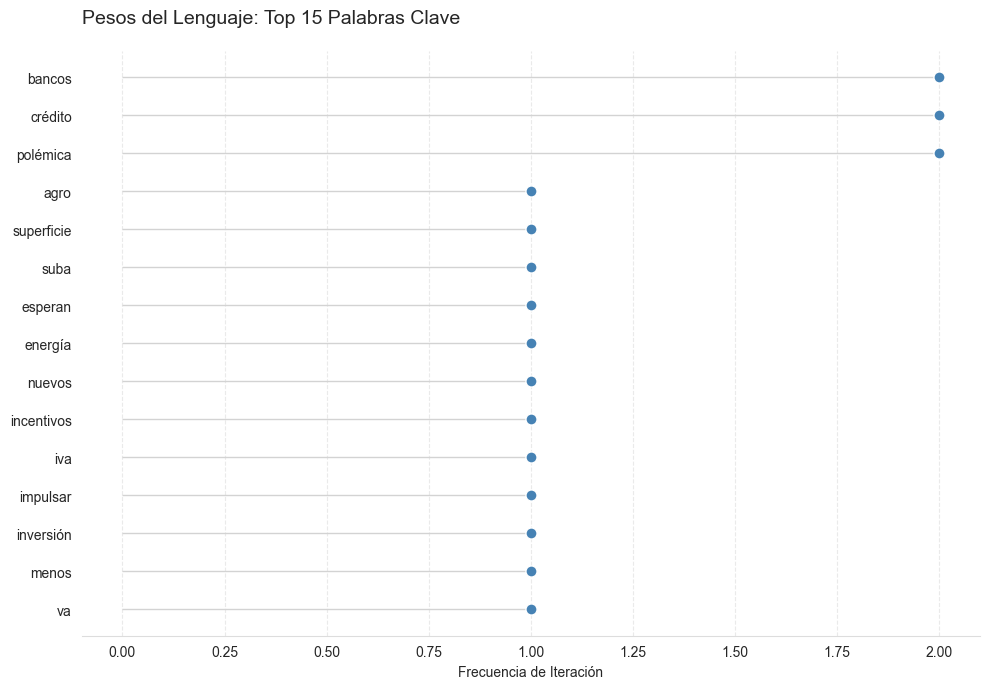

In [58]:
grafico_seccion(df, 'POLÍTICA Y ECONOMÍA')

In [53]:
seccion(df, 'TECNOLOGíA')

,seccion,titulo
92,TECNOLOGÍA,Adiós al Wi-Fi rápido. El electrodoméstico que...
93,TECNOLOGÍA,Paso a paso. Cómo activar el “modo capibara” e...
94,TECNOLOGÍA,Paso a paso. Pasá tu CV por la IA y hacelo inf...


In [ ]:
# EJERCICIO FINAL: Construir y lanzar la Interfaz Dinámica con Gradio


